<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-2026-player-eda-100?scriptVersionId=328155619" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/swaptr/fifa-wc-2026-players/players.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/swaptr/fifa-wc-2026-players/players.csv")

In [3]:
df.head()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,27-003,1999,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23-047,2003,NaN,1,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amine Gouiri,Algeria,Algeria,FW,26-122,2000,Marseille,1,1,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anis Hadj Moussa,Algeria,Algeria,MF,24-127,2002,Feyenoord,1,1,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aïssa Mandi,Algeria,Algeria,DF,34-239,1991,Lille,1,1,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
1030,Rodrigo Zalazar,Uruguay,Uruguay,"FW,MF",26-310,1999,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1031,Santiago Bueno,Uruguay,Uruguay,DF,27-221,1998,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1032,Santiago Mele,Uruguay,Uruguay,GK,28-285,1997,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1033,Sebastián Cáceres,Uruguay,Uruguay,DF,26-304,1999,América,1,1,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1034,Sergio Rochet,Uruguay,Uruguay,GK,33-087,1993,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1035 non-null   object 
 1   team                        1035 non-null   object 
 2   team_country                1035 non-null   object 
 3   position                    1035 non-null   object 
 4   age                         1035 non-null   object 
 5   birth_year                  1035 non-null   int64  
 6   club                        556 non-null    object 
 7   games                       1035 non-null   int64  
 8   games_starts                1035 non-null   int64  
 9   minutes                     627 non-null    float64
 10  minutes_90s                 627 non-null    float64
 11  goals                       627 non-null    float64
 12  assists                     627 non-null    float64
 13  goals_assists               627 n

In [6]:
df.describe()

,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
count,1035.000000,1035.000000,1035.000000,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.0,40.0,3.0
mean,1998.168116,0.605797,0.425121,63.079745,0.700957,0.092504,0.071770,0.164274,0.087719,0.004785,...,0.300000,0.400000,0.300000,0.175000,17.500000,0.075000,0.075000,0.0,0.0,0.0
std,4.264326,0.488915,0.494600,31.342232,0.349668,0.335909,0.287576,0.455845,0.325133,0.069061,...,0.464095,0.496139,0.464095,0.384808,38.480764,0.266747,0.266747,0.0,0.0,0.0
min,1982.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
25%,1995.000000,0.000000,0.000000,30.000000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
50%,1998.000000,1.000000,0.000000,79.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
75%,2001.000000,1.000000,1.000000,90.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
max,2008.000000,1.000000,1.000000,90.000000,1.000000,3.000000,2.000000,3.000000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,0.0,0.0,0.0


In [7]:
df.isnull()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,False,False,False,False,False,False,True,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,True,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,False,False,False,False,False,False,True,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1031,False,False,False,False,False,False,True,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1032,False,False,False,False,False,False,True,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1033,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True


In [8]:
df.isnull().sum()

player                 0
team                   0
team_country           0
position               0
age                    0
                    ... 
gk_pens_att          995
gk_pens_allowed      995
gk_pens_saved        995
gk_pens_missed       995
gk_pens_save_pct    1032
Length: 72, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

player               object
team                 object
team_country         object
position             object
age                  object
                     ...   
gk_pens_att         float64
gk_pens_allowed     float64
gk_pens_saved       float64
gk_pens_missed      float64
gk_pens_save_pct    float64
Length: 72, dtype: object

In [11]:
df.shape

(1035, 72)

In [12]:
df.columns

Index(['player', 'team', 'team_country', 'position', 'age', 'birth_year',
       'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals',
       'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att',
       'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_game', 'minutes_pct', 'minutes_per_start',
       'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs',
       'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus',
       'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls',
       'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won',
       'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts',
       'gk_minutes', 'gk_goals_against', 

In [13]:
df.nunique()

player              1034
team                  40
team_country          40
position               7
age                  944
                    ... 
gk_pens_att            2
gk_pens_allowed        2
gk_pens_saved          1
gk_pens_missed         1
gk_pens_save_pct       1
Length: 72, dtype: int64

## EDA

Dataset Shape: (1035, 72)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1035 non-null   object 
 1   team                        1035 non-null   object 
 2   team_country                1035 non-null   object 
 3   position                    1035 non-null   object 
 4   age                         1035 non-null   object 
 5   birth_year                  1035 non-null   int64  
 6   club                        556 non-null    object 
 7   games                       1035 non-null   int64  
 8   games_starts                1035 non-null   int64  
 9   minutes                     627 non-null    float64
 10  minutes_90s                 627 non-null    float64
 11  goals                       627 non-null    float64
 12  assists                     627 non-null    float64
 13  goals_a

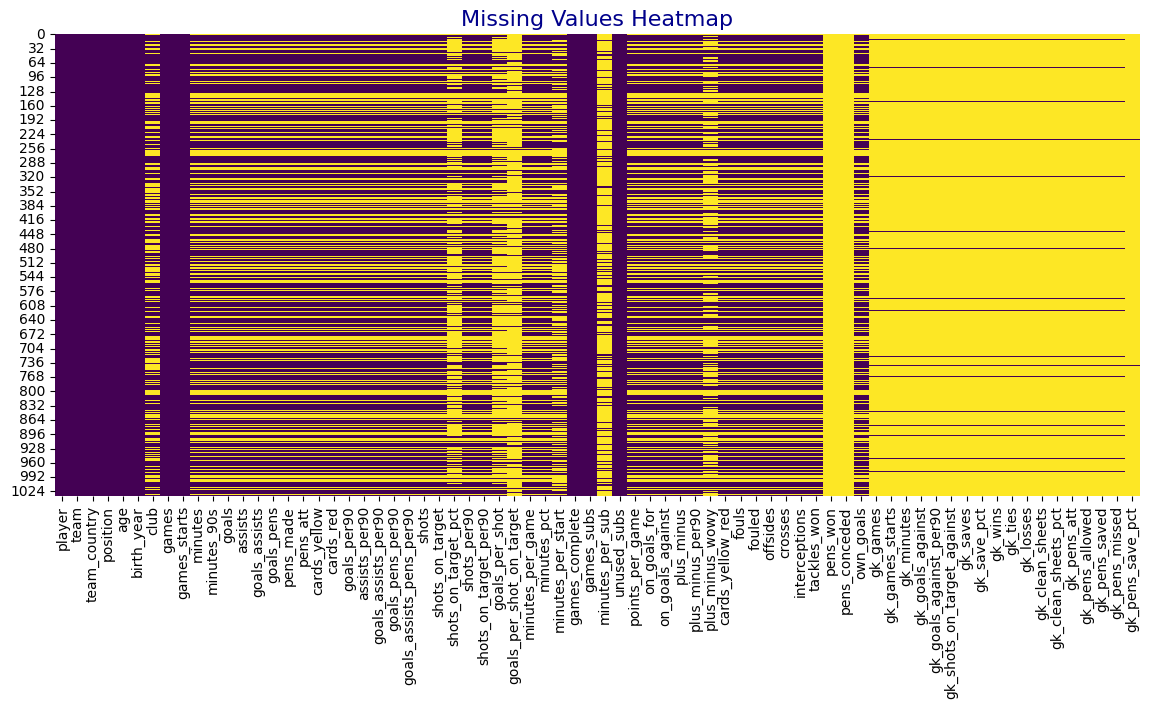

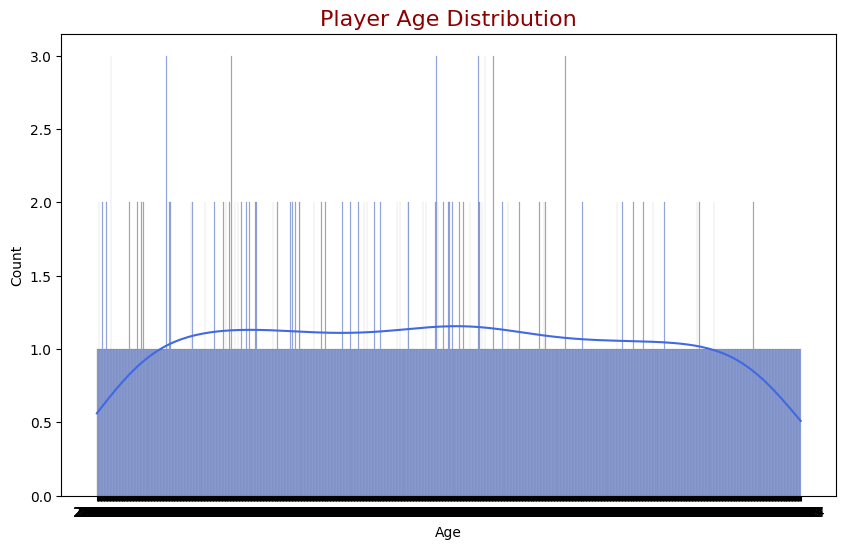

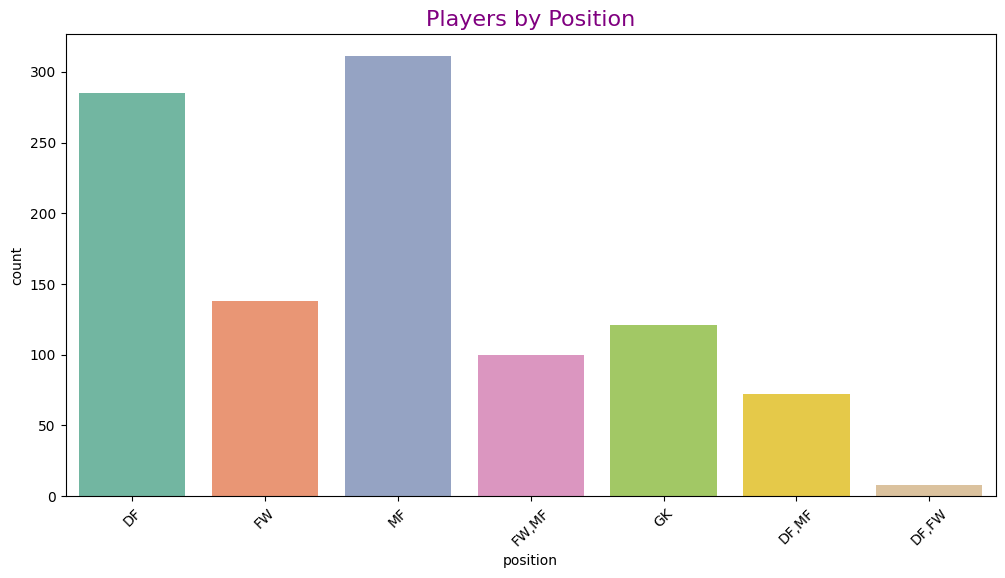

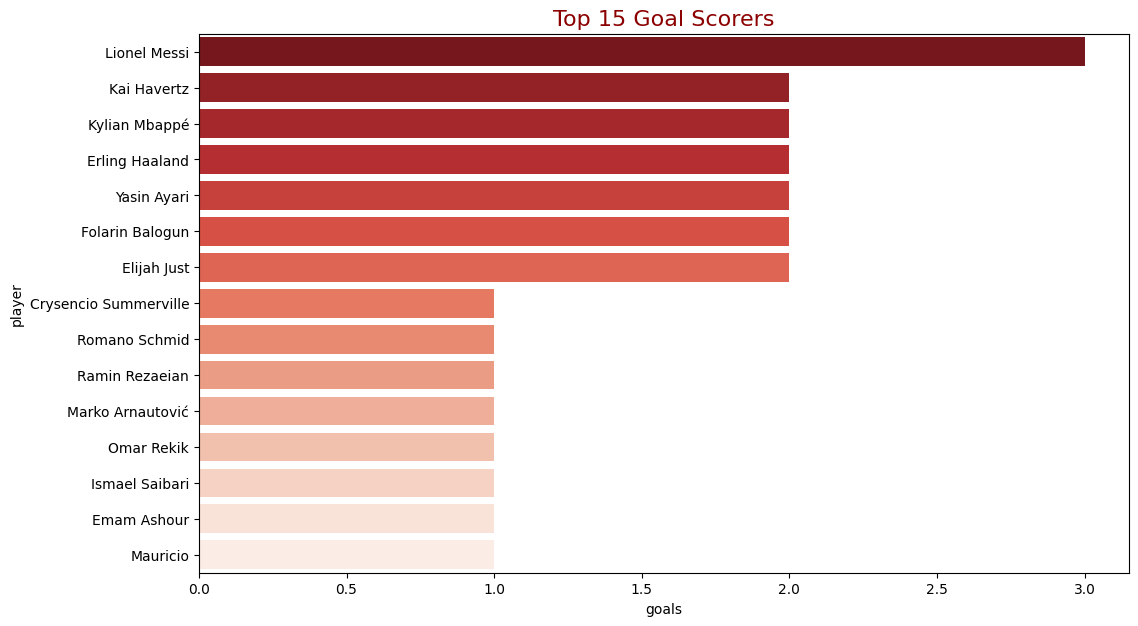

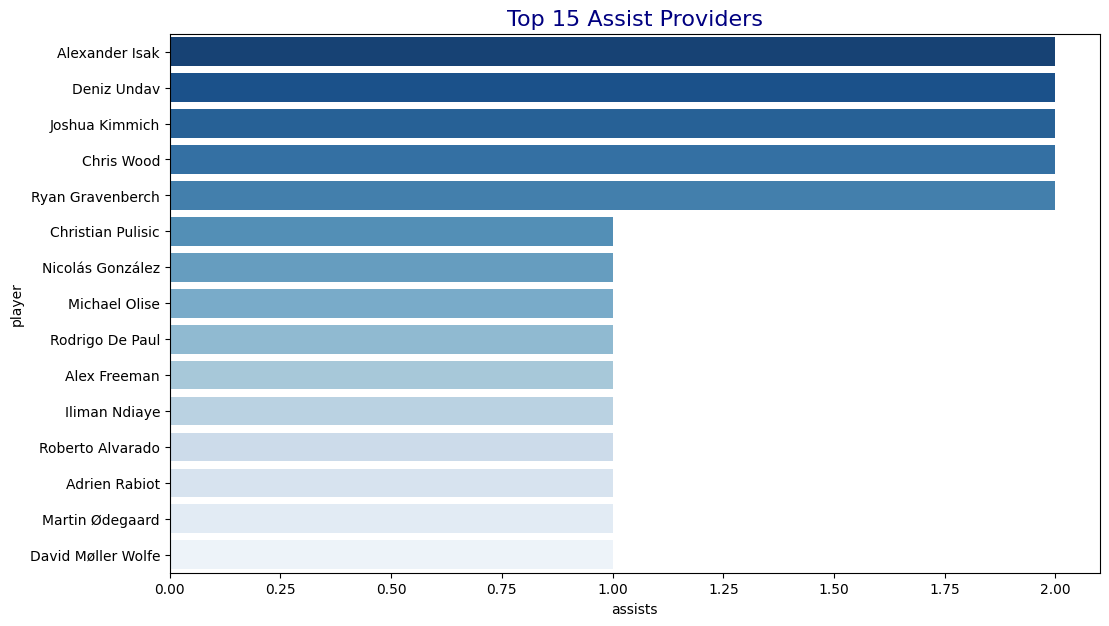

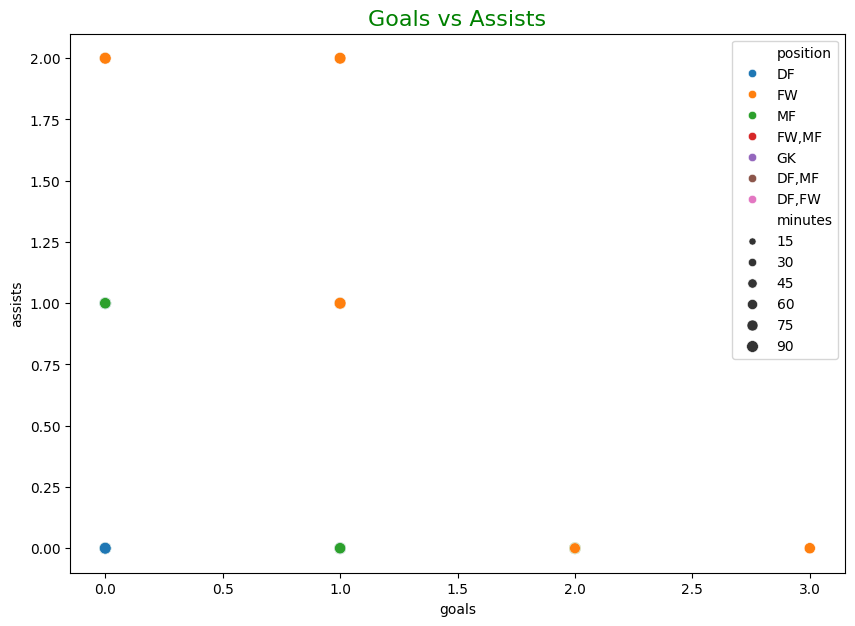

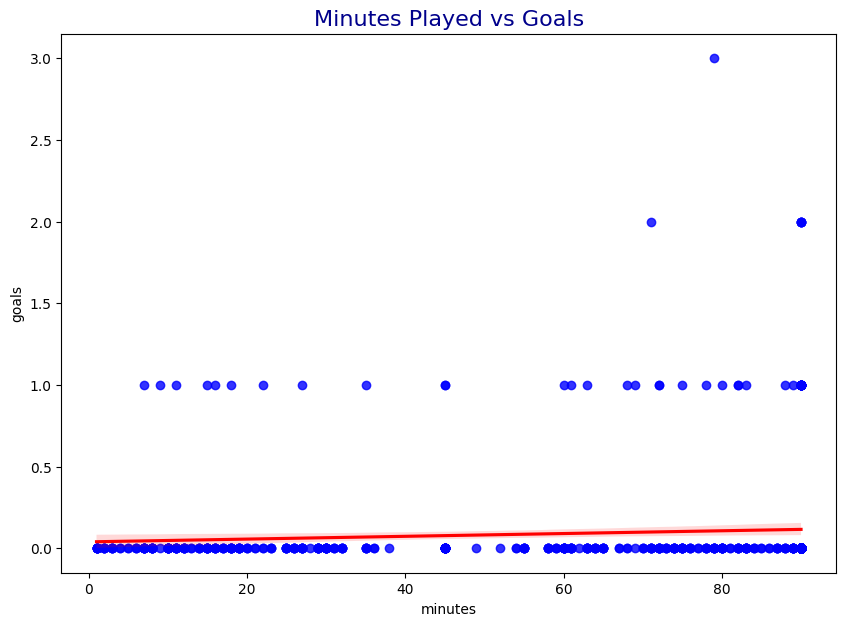

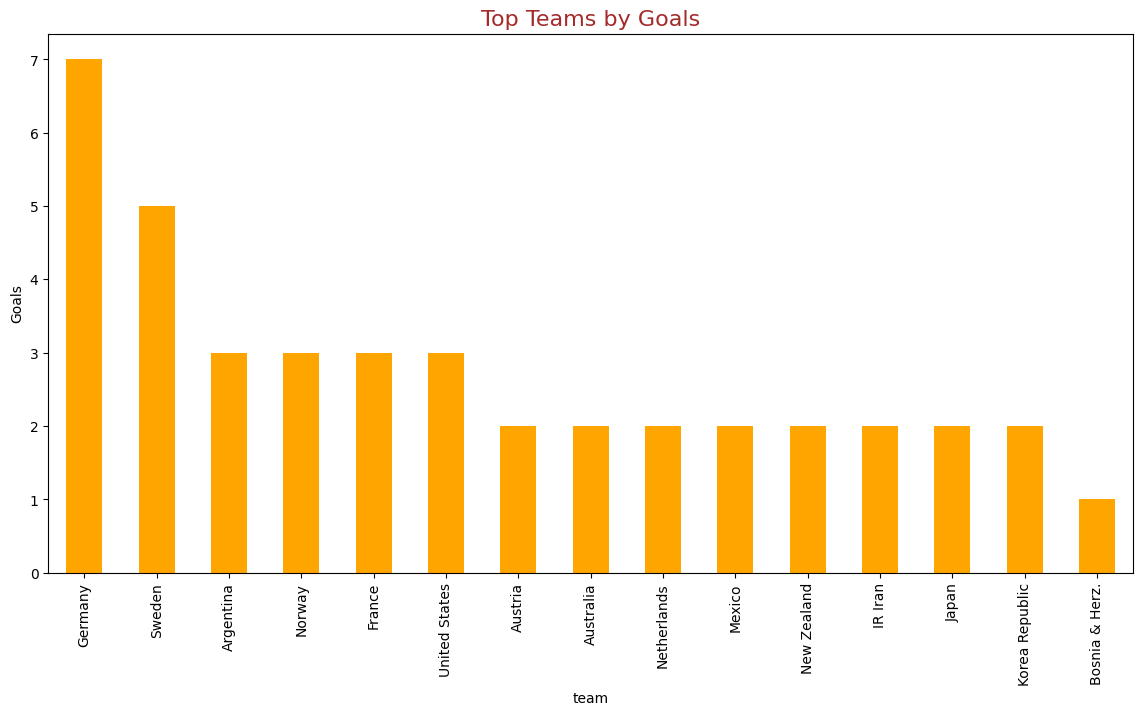

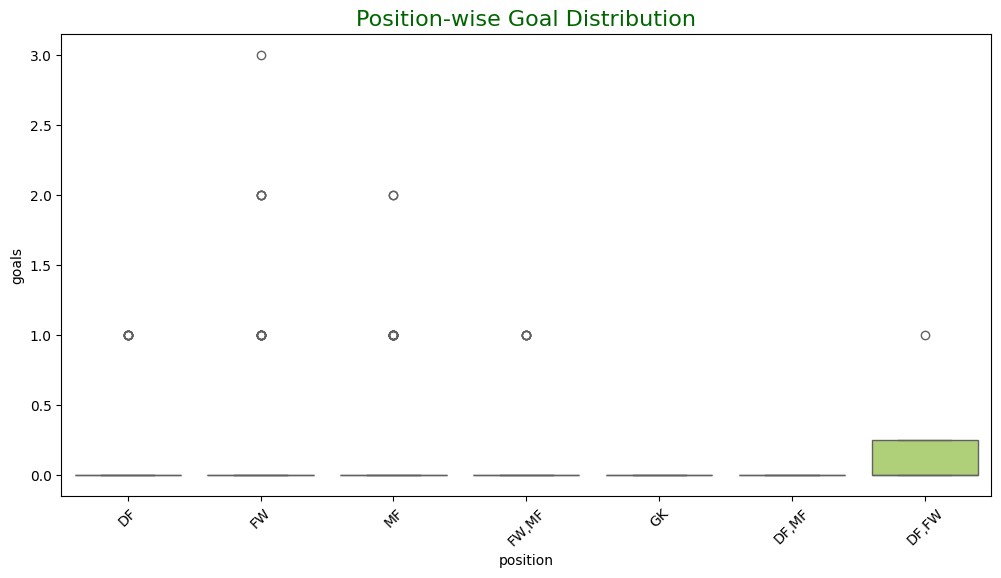

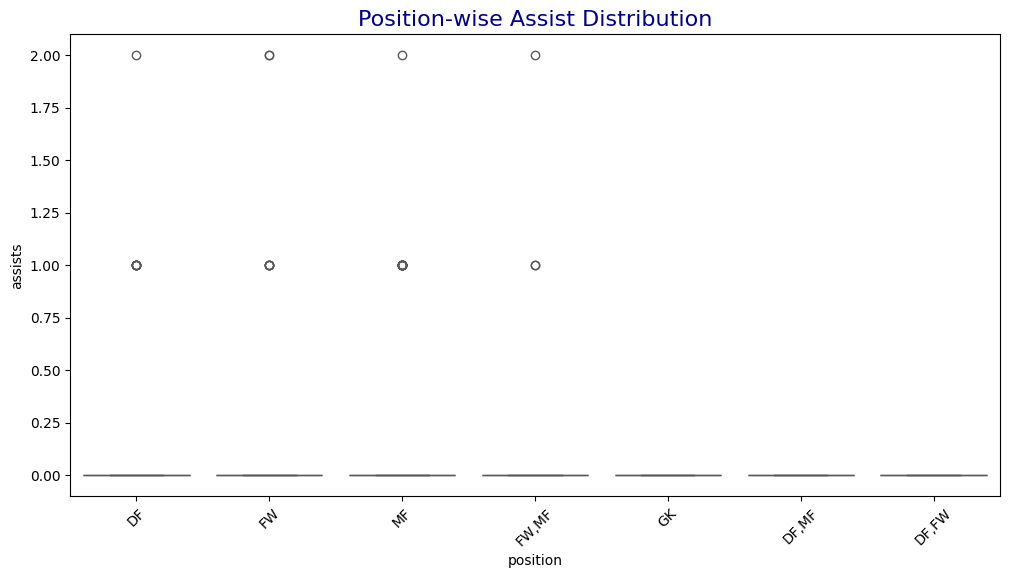

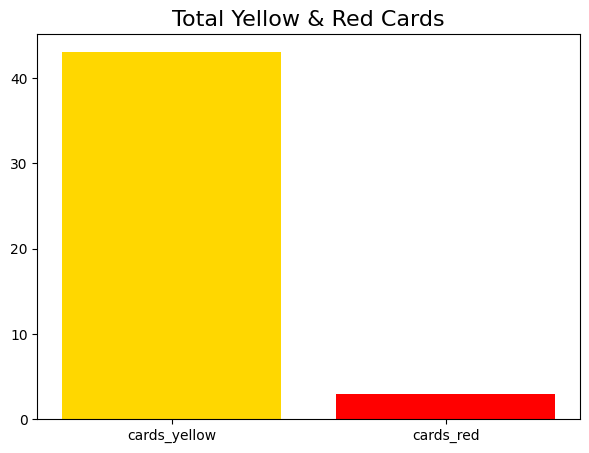

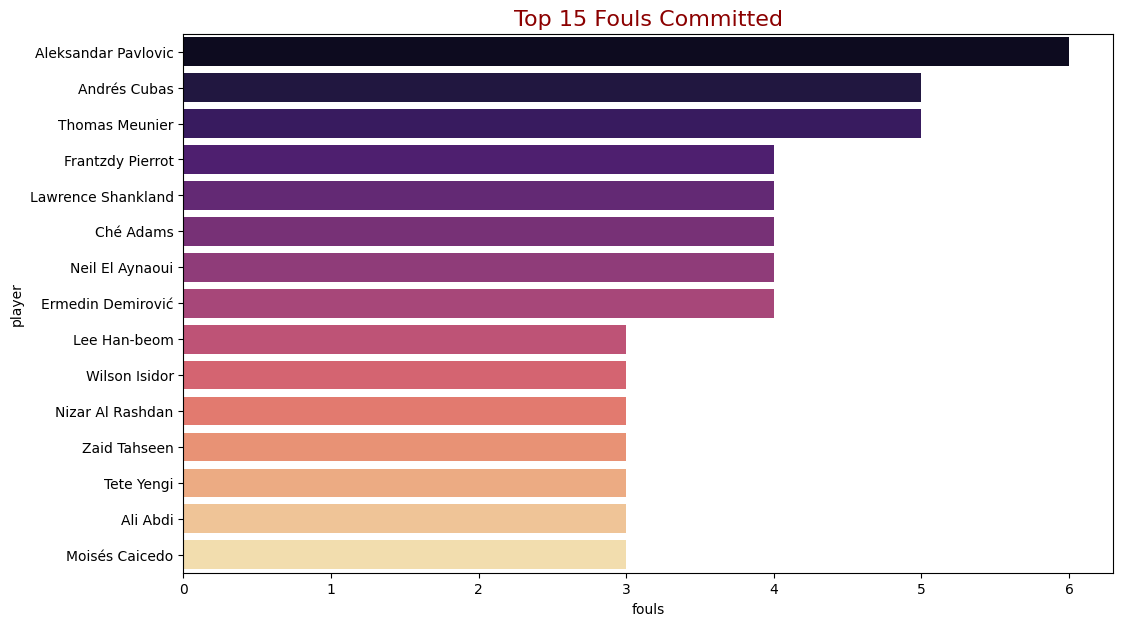

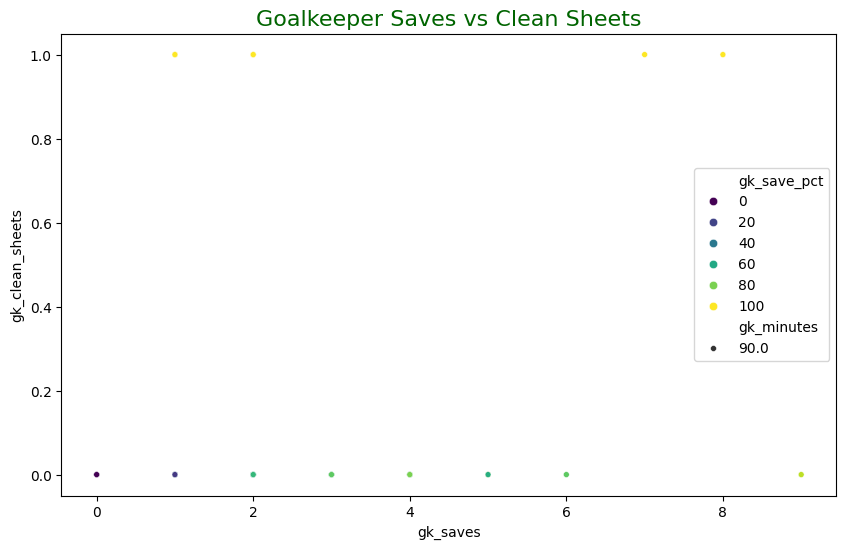

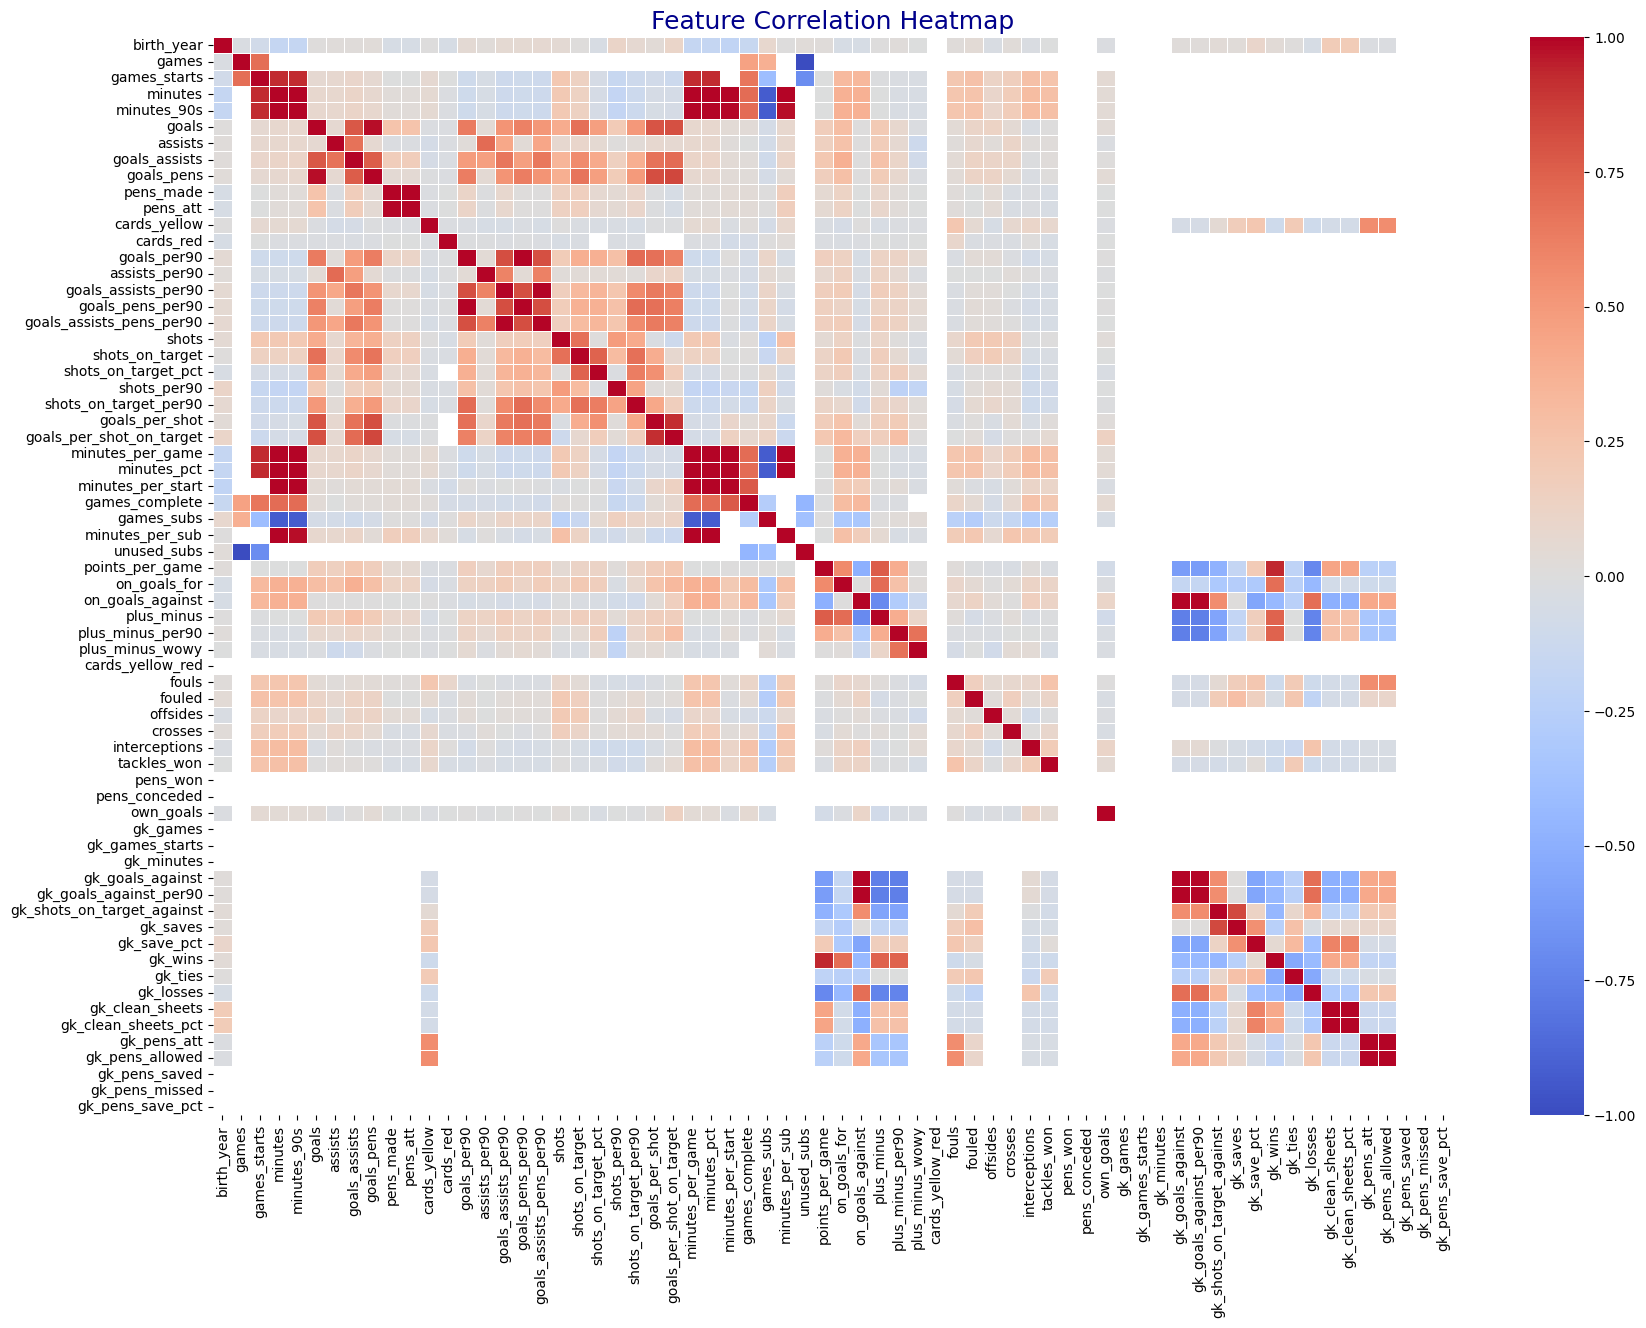

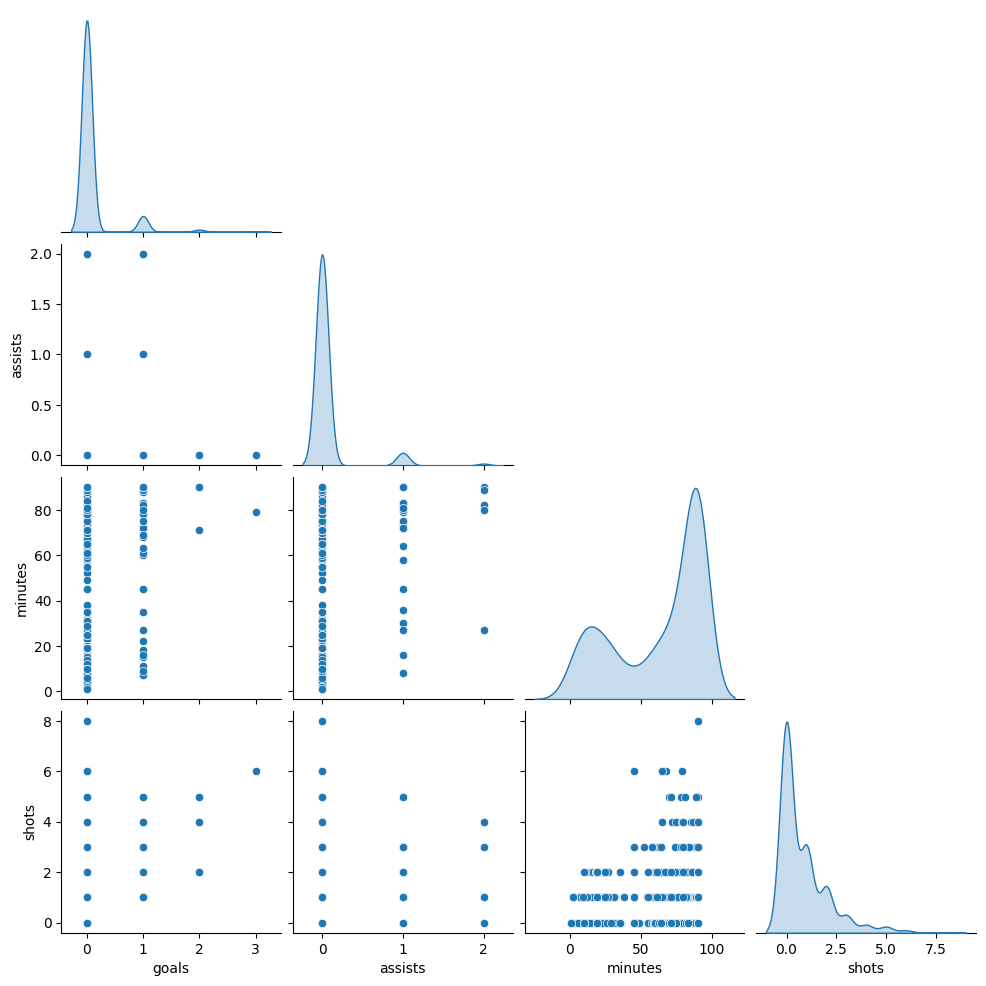

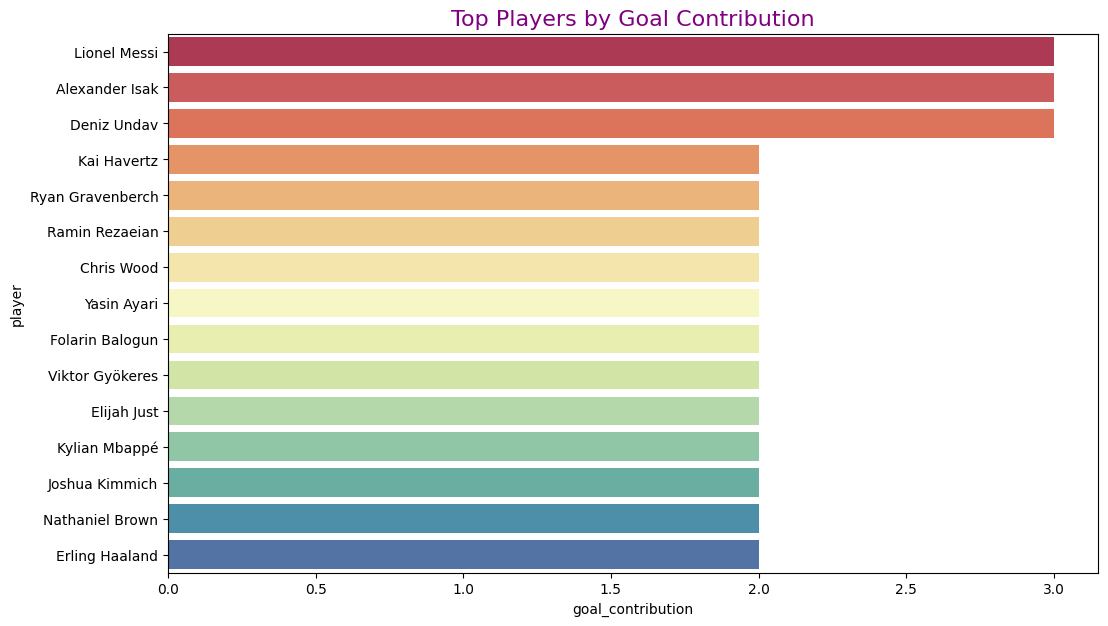

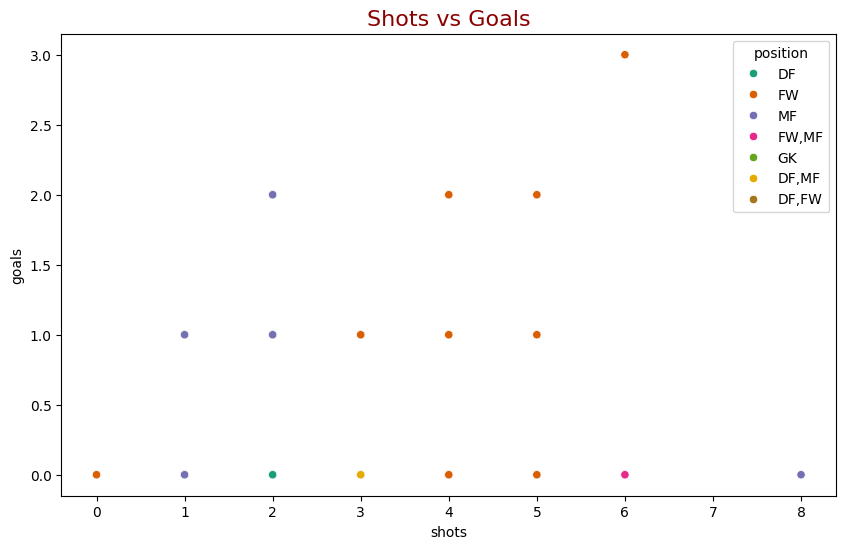

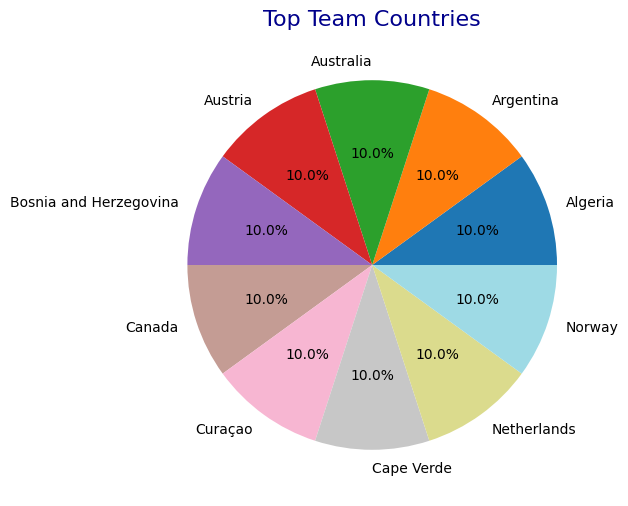

Visualization Completed Successfully!


In [14]:
print("Dataset Shape:", df.shape)
print(df.info())

# =====================================
# MISSING VALUES
# =====================================
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')
plt.title('Missing Values Heatmap',
          fontsize=16,
          color='darkblue')
plt.show()

# =====================================
# AGE DISTRIBUTION
# =====================================
plt.figure(figsize=(10,6))
sns.histplot(df['age'],
             bins=20,
             kde=True,
             color='royalblue')

plt.title('Player Age Distribution',
          fontsize=16,
          color='darkred')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# =====================================
# POSITION DISTRIBUTION
# =====================================
plt.figure(figsize=(12,6))

sns.countplot(
    x='position',
    data=df,
    palette='Set2'
)

plt.title('Players by Position',
          fontsize=16,
          color='purple')
plt.xticks(rotation=45)
plt.show()

# =====================================
# TOP 15 GOAL SCORERS
# =====================================
top_goals = df.sort_values(
    'goals',
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    x='goals',
    y='player',
    data=top_goals,
    palette='Reds_r'
)

plt.title('Top 15 Goal Scorers',
          fontsize=16,
          color='darkred')
plt.show()

# =====================================
# TOP 15 ASSIST PROVIDERS
# =====================================
top_assists = df.sort_values(
    'assists',
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    x='assists',
    y='player',
    data=top_assists,
    palette='Blues_r'
)

plt.title('Top 15 Assist Providers',
          fontsize=16,
          color='navy')
plt.show()

# =====================================
# GOALS VS ASSISTS
# =====================================
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='goals',
    y='assists',
    hue='position',
    size='minutes',
    palette='tab10',
    data=df
)

plt.title('Goals vs Assists',
          fontsize=16,
          color='green')
plt.show()

# =====================================
# MINUTES VS GOALS
# =====================================
plt.figure(figsize=(10,7))

sns.regplot(
    x='minutes',
    y='goals',
    data=df,
    scatter_kws={'color':'blue'},
    line_kws={'color':'red'}
)

plt.title('Minutes Played vs Goals',
          fontsize=16,
          color='darkblue')
plt.show()

# =====================================
# TEAM GOALS ANALYSIS
# =====================================
team_goals = (
    df.groupby('team')['goals']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))

team_goals.plot(
    kind='bar',
    color='orange'
)

plt.title('Top Teams by Goals',
          fontsize=16,
          color='brown')
plt.ylabel('Goals')
plt.show()

# =====================================
# POSITION VS GOALS
# =====================================
plt.figure(figsize=(12,6))

sns.boxplot(
    x='position',
    y='goals',
    data=df,
    palette='Set3'
)

plt.title('Position-wise Goal Distribution',
          fontsize=16,
          color='darkgreen')

plt.xticks(rotation=45)
plt.show()

# =====================================
# POSITION VS ASSISTS
# =====================================
plt.figure(figsize=(12,6))

sns.boxplot(
    x='position',
    y='assists',
    data=df,
    palette='coolwarm'
)

plt.title('Position-wise Assist Distribution',
          fontsize=16,
          color='darkblue')

plt.xticks(rotation=45)
plt.show()

# =====================================
# CARDS ANALYSIS
# =====================================
cards = df[['cards_yellow',
            'cards_red']].sum()

plt.figure(figsize=(7,5))

plt.bar(
    cards.index,
    cards.values,
    color=['gold','red']
)

plt.title('Total Yellow & Red Cards',
          fontsize=16)
plt.show()

# =====================================
# TOP FOUL COMMITTERS
# =====================================
top_fouls = (
    df.sort_values(
        'fouls',
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x='fouls',
    y='player',
    data=top_fouls,
    palette='magma'
)

plt.title('Top 15 Fouls Committed',
          fontsize=16,
          color='darkred')
plt.show()

# =====================================
# GOALKEEPER ANALYSIS
# =====================================
gk = df[df['gk_minutes'] > 0]

if len(gk) > 0:

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        x='gk_saves',
        y='gk_clean_sheets',
        hue='gk_save_pct',
        palette='viridis',
        size='gk_minutes',
        data=gk
    )

    plt.title(
        'Goalkeeper Saves vs Clean Sheets',
        fontsize=16,
        color='darkgreen'
    )
    plt.show()

# =====================================
# CORRELATION HEATMAP
# =====================================
numeric_cols = df.select_dtypes(
    include=np.number
)

corr = numeric_cols.corr()

plt.figure(figsize=(20,14))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=18,
    color='darkblue'
)

plt.show()

# =====================================
# PAIRPLOT
# =====================================
features = [
    'age',
    'goals',
    'assists',
    'minutes',
    'shots'
]

sns.pairplot(
    df[features].dropna(),
    diag_kind='kde',
    corner=True
)

plt.show()

# =====================================
# TOP PLAYERS BY GOAL CONTRIBUTION
# =====================================
df['goal_contribution'] = (
    df['goals'] +
    df['assists']
)

top_gc = (
    df.sort_values(
        'goal_contribution',
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x='goal_contribution',
    y='player',
    data=top_gc,
    palette='Spectral'
)

plt.title(
    'Top Players by Goal Contribution',
    fontsize=16,
    color='purple'
)

plt.show()

# =====================================
# SHOTS VS GOALS
# =====================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='shots',
    y='goals',
    hue='position',
    palette='Dark2',
    data=df
)

plt.title(
    'Shots vs Goals',
    fontsize=16,
    color='darkred'
)

plt.show()

# =====================================
# TEAM COUNTRY DISTRIBUTION
# =====================================
top_country = (
    df['team_country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_country.plot(
    kind='pie',
    autopct='%1.1f%%',
    cmap='tab20'
)

plt.title(
    'Top Team Countries',
    fontsize=16,
    color='darkblue'
)

plt.ylabel('')
plt.show()

print("Visualization Completed Successfully!")

## Feature engineering

[](http://)

In [15]:
# 0 = Low Performer

df['target'] = (df['goals'] >= df['goals'].median()).astype(int)

print(df['target'].value_counts())

target
1    627
0    408
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [17]:
df['target'] = (
    df['goals'] >= df['goals'].median()
).astype(int)

In [18]:
leakage_cols = [
    'goals',
    'goals_per90',
    'goals_assists',
    'goals_assists_per90',
    'goals_pens',
    'goals_pens_per90',
    'goals_assists_pens_per90'
]

X = df.drop(
    columns=leakage_cols + ['target'],
    errors='ignore'
)

y = df['target']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)


Training Shape : (828, 66)
Testing Shape  : (207, 66)


In [20]:
categorical_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

In [21]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [22]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}




Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       125

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207



Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       125

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       125

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1

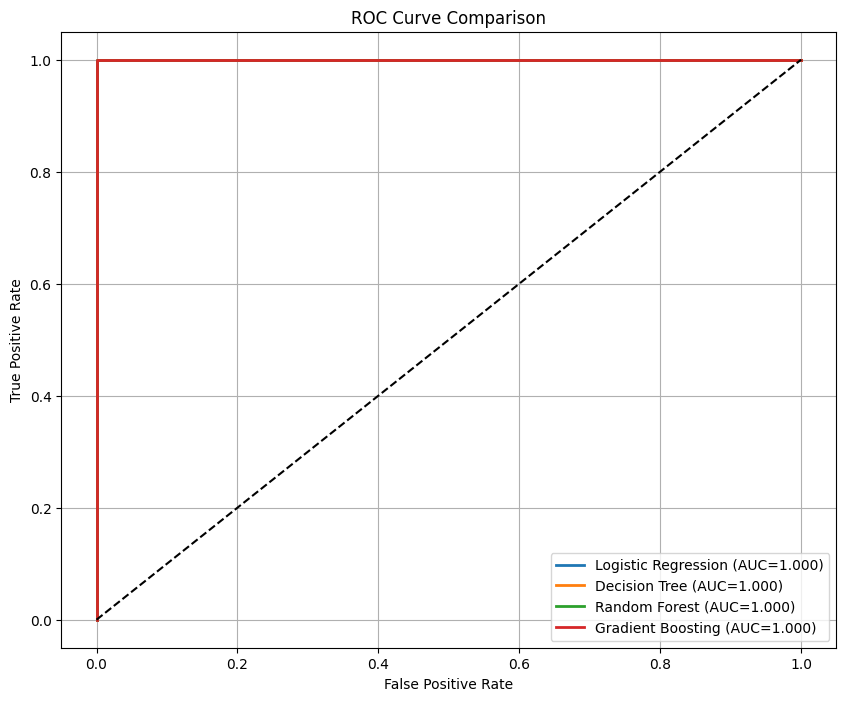

In [23]:
results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train only on train data
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probabilities for ROC
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        roc_auc
    ])

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={roc_auc:.3f})'
    )

# ROC Plot
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       1.0        1.0     1.0       1.0      1.0
2        Random Forest       1.0        1.0     1.0       1.0      1.0
3    Gradient Boosting       1.0        1.0     1.0       1.0      1.0


In [25]:
best_model_name = results_df.iloc[0]['Model']

print("\nBest Model :", best_model_name)


Best Model : Logistic Regression


## Thank you...pls upvote!!!!!!!!!!!!!!